In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [7]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [ ]:
X=df.drop(columns='Survived')
Y=df['Survived']

In [10]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=2,test_size=0.2)

In [12]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [13]:
X_train.isnull().mean()*100

Age       20.786517
Fare       5.056180
Family     0.000000
dtype: float64

In [15]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [24]:
X_train['mean_age']=X_train['Age'].fillna(mean_age)
X_train['median_age']=X_train['Age'].fillna(median_age)

X_train['mean_fare']=X_train['Fare'].fillna(mean_fare)
X_train['median_fare']=X_train['Fare'].fillna(median_fare)

In [25]:
X_train.sample(5)

,Age,Fare,Family,mean_age,medaian_age,mean_fare,medaian_fare,median_age,median_fare
852,9.0,15.2458,2,9.000000,9.00,15.2458,15.2458,9.00,15.2458
629,NaN,7.7333,0,29.785904,28.75,7.7333,7.7333,28.75,7.7333
45,NaN,8.0500,0,29.785904,28.75,8.0500,8.0500,28.75,8.0500
11,58.0,26.5500,0,58.000000,58.00,26.5500,26.5500,58.00,26.5500
411,NaN,6.8583,0,29.785904,28.75,6.8583,6.8583,28.75,6.8583


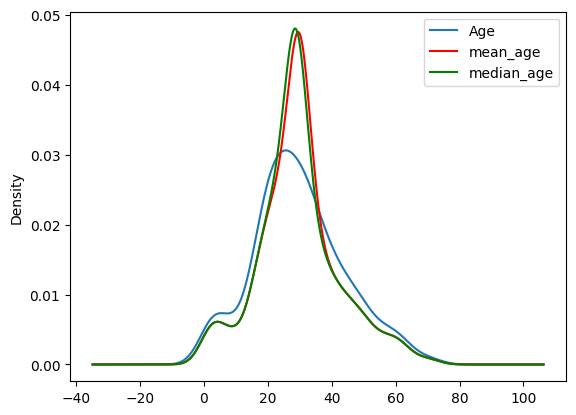

In [27]:
fig=plt.figure()
ax=fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)
X_train['mean_age'].plot(kind='kde',ax=ax,color='red')
X_train['median_age'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')